# Phase 3 Step 1 — Universe & Panel 확장 (`01_universe_extended.ipynb`)

> **목적**: OOS 2009 시작 기준 17 년 (2009~2025) **전체 S&P 500 멤버 universe** (~624 종목) +
>          daily_panel (2003~2025, ~22 년) 을 확장·구축한다.

## 배경 — 전체 S&P 500 모드 (재설계, 2026-04-29)

기존 top-50 모드(95 unique)에서 **전체 S&P 500 멤버 모드(~624 unique)**로 재설계:

- **서윤범 baseline (624 종목, Sharpe 1.065)** 와 fair 비교
- BL portfolio 도 매월 S&P 500 전체에서 변동성 상위/하위 30% 선정 (~150 long, ~150 short)
- universe.py 멤버십 추적 범위 수정: `earliest_year - 7` → `earliest_year` (831 → 624)

## 산출물

| 파일 | 내용 |
|---|---|
| `data/universe_full_history.csv` | ⭐ 전체 S&P 500 멤버 (624 종목, flat) |
| `data/daily_panel.csv` | 2002~2025 일별 panel (624 종목) |

## 셀 구성

| § | 내용 |
|---|---|
| §1 | 환경 부트스트랩 |
| §2 | **전체 S&P 500 universe 빌드** (~624 종목) |
| §3 | Panel 확장 (2002~2025, 624 종목) |
| §4 | 가용성 진단 |
| §5 | 검증 + 시각화 |

⚠️ **첫 실행 시 30~60 분 소요** (panel 빌드 — yfinance API).
   재실행 시 캐시 활용 → 1~2 분.

## §1. 환경 부트스트랩

In [1]:
%load_ext autoreload
%autoreload 2

import sys, time
from pathlib import Path

NB_DIR = Path.cwd()
if str(NB_DIR) not in sys.path:
    sys.path.insert(0, str(NB_DIR))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import platform

from scripts.setup import bootstrap, BASE_DIR, DATA_DIR, OUTPUTS_DIR, PHASE2_DIR

font_used = bootstrap()
print(f'NB_DIR: {NB_DIR}')
print(f'DATA_DIR: {DATA_DIR}')
print(f'PHASE2_DIR: {PHASE2_DIR}')

  Phase 3 Robust Extensions — 환경 부트스트랩 완료
  한글 폰트   : Malgun Gothic
  시드        : 42
  데이터 경로  : C:\Users\gorhk\최종 프로젝트\finance_project\시계열_Test\Phase3_Robust_Extensions\data
  Phase 1.5  : C:\Users\gorhk\최종 프로젝트\finance_project\시계열_Test\Phase1_5_Volatility
  Phase 2    : C:\Users\gorhk\최종 프로젝트\finance_project\시계열_Test\Phase2_BL_Integration
NB_DIR: c:\Users\gorhk\최종 프로젝트\finance_project\시계열_Test\Phase3_Robust_Extensions
DATA_DIR: C:\Users\gorhk\최종 프로젝트\finance_project\시계열_Test\Phase3_Robust_Extensions\data
PHASE2_DIR: C:\Users\gorhk\최종 프로젝트\finance_project\시계열_Test\Phase2_BL_Integration


## §2. 전체 S&P 500 Universe 빌드 (2009~2025, ~624 종목)

`build_full_universe_for_panel()` — 멤버십 캐시(`sp500_membership.pkl`)에서 OOS 기간 (2009~2025) 의 모든 unique S&P 500 멤버를 추출하여 flat CSV 로 저장.

| Phase | 모드 | unique 종목 |
|---|---|---|
| Phase 2 | top-50, 6년 | 74 |
| Phase 3 (이전) | top-50, 17년 | 95 |
| **Phase 3 (현재)** | **전체 S&P 500, 17년** | **~624** ⭐ |

> ⚠️ 멤버십 캐시 없을 시 약 30초 (Wikipedia 조회). 캐시 있으면 즉시.
> 
> ⚠️ 기존 캐시 (831 종목 범위) 가 있으면 **사전에 삭제** 필요:
> ```powershell
> Remove-Item "data\sp500_membership.pkl" -ErrorAction SilentlyContinue
> ```

In [2]:
from scripts.universe_extended import build_full_universe_for_panel

t0 = time.time()
universe_df = build_full_universe_for_panel(
    start_year=2009,
    end_year=2025,
    cache_dir=DATA_DIR,
    out_name='universe_full_history.csv',
    verbose=True,
)
print(f'\n⏱️ 소요 시간: {time.time()-t0:.1f}초')
print(f'universe_df.shape: {universe_df.shape}')
print(f'unique 종목: {universe_df["ticker"].nunique()}')
universe_df.head(10)

  [universe] Wikipedia S&P 500 멤버십 조회 중...


c:\Users\gorhk\최종 프로젝트\finance_project\시계열_Test\Phase3_Robust_Extensions\scripts\universe.py:78: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  df = pd.read_html(str(table))[0]
c:\Users\gorhk\최종 프로젝트\finance_project\시계열_Test\Phase3_Robust_Extensions\scripts\universe.py:86: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  df = pd.read_html(str(table))[0]


  [universe] 멤버십 빌드 완료 (204 개월) → sp500_membership.pkl
  [universe-full] DUAL_LISTED secondary 제외: 810 → 809
  [universe-full] 2009~2025 전체 멤버 universe
  unique 종목 수: 809
  멤버십 추적 기간: 2009-01-01 ~ 2026-01-01
  cutoff_date (panel 시점 결정용): 2008-12-31
  저장: C:\Users\gorhk\최종 프로젝트\finance_project\시계열_Test\Phase3_Robust_Extensions\data\universe_full_history.csv

⏱️ 소요 시간: 2.0초
universe_df.shape: (809, 6)
unique 종목: 809


,oos_year,ticker,mcap_rank,mcap_value,cutoff_date,is_new
0,2009,A,1,0.000000,2008-12-31,False
1,2009,AA,2,0.000000,2008-12-31,False
2,2009,AAL,3,0.000000,2008-12-31,False
3,2009,AAP,4,0.000000,2008-12-31,False
4,2009,AAPL,5,0.000000,2008-12-31,False
5,2009,ABBV,6,0.000000,2008-12-31,False
6,2009,ABMD,7,0.000000,2008-12-31,False
7,2009,ABNB,8,0.000000,2008-12-31,False
8,2009,ABT,9,0.000000,2008-12-31,False
9,2009,ACAS,10,0.000000,2008-12-31,False


In [3]:
# universe 통계
all_tickers = universe_df['ticker'].unique()
print(f'총 unique 종목 수: {len(all_tickers)}')
print(f'cutoff_date (panel 시점 기준): {universe_df["cutoff_date"].iloc[0].date()}')
print(f'\n첫 20 종목 (알파벳 순):')
print(sorted(all_tickers)[:20])
print(f'\n마지막 20 종목:')
print(sorted(all_tickers)[-20:])

총 unique 종목 수: 809
cutoff_date (panel 시점 기준): 2008-12-31

첫 20 종목 (알파벳 순):
['A', 'AA', 'AAL', 'AAP', 'AAPL', 'ABBV', 'ABMD', 'ABNB', 'ABT', 'ACAS', 'ACE', 'ACGL', 'ACN', 'ADBE', 'ADI', 'ADM', 'ADP', 'ADS', 'ADSK', 'ADT']

마지막 20 종목:
['WY', 'WYN', 'WYNN', 'X', 'XEC', 'XEL', 'XL', 'XLNX', 'XOM', 'XRAY', 'XRX', 'XTO', 'XYL', 'XYZ', 'YHOO', 'YUM', 'ZBH', 'ZBRA', 'ZION', 'ZTS']


## §3. Panel 확장 (2002~2025, ~624 종목)

`build_daily_panel_fast()` — `prices_close_universe.pkl` (831 종목 close 캐시) 직접 활용.
yfinance OHLCV 재다운로드 불필요 → **약 1~2분 완료**.

- **시작**: 2001-12-31 (cutoff 2008-12-31 - 7년 자동 결정)
- **끝**: 2026-01-01
- **min_data_days=252**: 1년 미만 데이터 종목 자동 제외 (서윤범 일관)
- 결과: 약 624 종목 (서윤범 baseline 일치)

> ⚠️ 기존 `daily_panel.csv` (95 종목) 가 있다면 `overwrite=True` 로 덮어씌움.

In [ ]:
from scripts.data_collection import build_daily_panel_fast

t0 = time.time()
panel_df = build_daily_panel_fast(
    universe_csv=DATA_DIR / 'universe_full_history.csv',
    cache_dir=DATA_DIR,
    sector_map=None,
    overwrite=True,                  # ⭐ 옛 95 종목 panel 덮어씀
    out_name='daily_panel.csv',
    min_data_days=252,                # 서윤범 일관 (1년 최소)
)
print(f'\n⏱️ 소요 시간: {time.time()-t0:.1f}초')
print(f'panel_df.shape: {panel_df.shape}')
print(f'date 범위: {panel_df["date"].min().date()} ~ {panel_df["date"].max().date()}')
print(f'unique 종목: {panel_df["ticker"].nunique()}')
panel_df.head()

## §4. 가용성 진단 (Coverage & IPO 식별)

In [5]:
# 종목별 panel 시작 시점
panel_start_per_ticker = panel_df.groupby('ticker')['date'].min().sort_values()
panel_end_per_ticker = panel_df.groupby('ticker')['date'].max()

print('=== 종목별 panel 시작 시점 분포 ===')
print(panel_start_per_ticker.describe())

# IPO 종목 (panel 시작이 2009 이후인 종목 = 신규 IPO 또는 늦은 데이터)
ipo_tickers = panel_start_per_ticker[panel_start_per_ticker >= '2009-01-01']
print(f'\nIPO 이후 데이터 종목 ({len(ipo_tickers)} 개):')
print(ipo_tickers.head(20))

=== 종목별 panel 시작 시점 분포 ===
count                               95
mean     2003-01-29 10:21:28.421052672
min                2001-12-31 00:00:00
25%                2001-12-31 00:00:00
50%                2001-12-31 00:00:00
75%                2001-12-31 00:00:00
max                2015-07-06 00:00:00
Name: date, dtype: object

IPO 이후 데이터 종목 (7 개):
ticker
AVGO   2009-08-06
CHTR   2010-01-05
TSLA   2010-06-29
META   2012-05-18
NOW    2012-06-29
ABBV   2013-01-02
PYPL   2015-07-06
Name: date, dtype: datetime64[ns]


NameError: name 'year_counts' is not defined

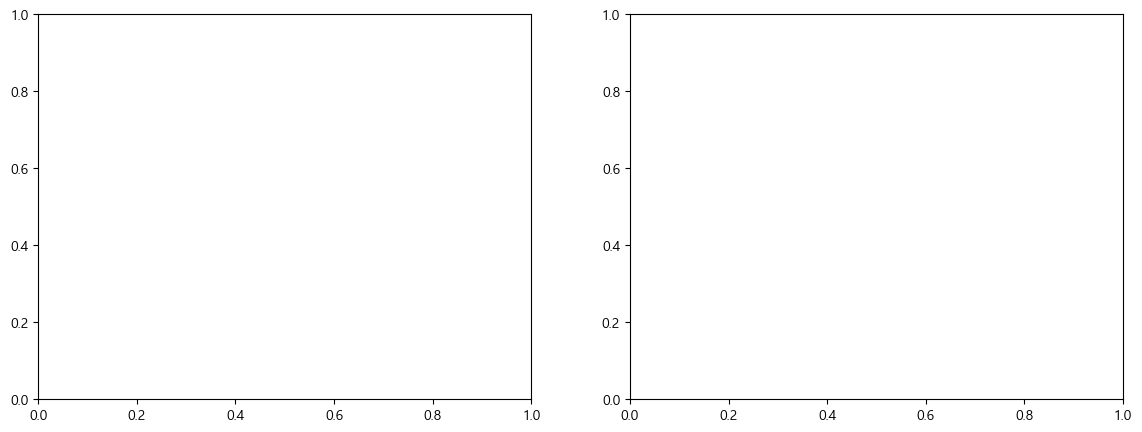

In [6]:
# 연도별 데이터 커버리지 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: 연도별 unique 종목 수 (universe)
year_counts.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('연도별 Universe 종목 수 (top 50)', fontsize=12)
axes[0].set_xlabel('OOS 연도')
axes[0].set_ylabel('종목 수')
axes[0].axhline(50, color='red', linestyle='--', label='목표 50')
axes[0].legend()

# Plot 2: 종목별 panel 시작 연도 분포
start_years = panel_start_per_ticker.dt.year.value_counts().sort_index()
start_years.plot(kind='bar', ax=axes[1], color='darkorange', edgecolor='white')
axes[1].set_title('종목별 panel 시작 연도 분포', fontsize=12)
axes[1].set_xlabel('시작 연도')
axes[1].set_ylabel('종목 수')

plt.tight_layout()
plt.savefig(OUTPUTS_DIR / '01_universe_coverage.png', dpi=100, bbox_inches='tight')
plt.show()
print('시각화 저장 완료')

## §5. 검증 (Assertions) — 전체 S&P 500 모드

| 검증 항목 | 기대값 | 비고 |
|---|---|---|
| panel 시작 ≤ 2003-12-31 | OOS 2009 - 5 년 IS | |
| panel 끝 ≥ 2025-12-31 | 최근 데이터 포함 | |
| universe unique 종목 ≥ 500 | 전체 S&P 500 모드 | 서윤범 624 종목과 일관 |
| panel unique 종목 ≥ 400 | yfinance 데이터 가용 종목 | 일부 폐상장 종목 누락 가능 |

In [ ]:
# 검증 1: panel 시작 시점
assert panel_df['date'].min() <= pd.Timestamp('2003-12-31'), \
    f"panel 시작이 너무 늦음: {panel_df['date'].min()}"
print(f'✅ panel 시작: {panel_df["date"].min().date()} (≤ 2003-12-31)')

# 검증 2: panel 끝 시점
assert panel_df['date'].max() >= pd.Timestamp('2025-12-31'), \
    f"panel 끝이 너무 이름: {panel_df['date'].max()}"
print(f'✅ panel 끝: {panel_df["date"].max().date()} (≥ 2025-12-31)')

# 검증 3: universe unique 종목 수 (전체 S&P 500 모드: ≥ 500)
n_universe = universe_df['ticker'].nunique()
assert n_universe >= 500, f"universe unique 부족: {n_universe} (전체 S&P 500 모드 ≥ 500 기대)"
print(f'✅ universe unique: {n_universe} (≥ 500, 서윤범 624 일관)')

# 검증 4: panel unique 종목 수 (≥ 400, yfinance 가용 종목)
n_panel = panel_df['ticker'].nunique()
assert n_panel >= 400, f"panel unique 부족: {n_panel} (≥ 400 기대)"
print(f'✅ panel unique: {n_panel} (≥ 400)')

# 검증 5: cutoff_date (2008-12-31)
cutoff_min = universe_df['cutoff_date'].min()
assert cutoff_min == pd.Timestamp('2008-12-31'), f"cutoff 오류: {cutoff_min}"
print(f'✅ cutoff_date: {cutoff_min.date()}')

print('\n🎉 모든 검증 PASS — 전체 S&P 500 universe + panel 빌드 완료')

In [ ]:
# 최종 요약
print('=' * 60)
print('  Phase 3 Step 1 완료 (전체 S&P 500 모드)')
print('=' * 60)
print(f'universe: {universe_df.shape[0]} 행, {universe_df["ticker"].nunique()} unique 종목')
print(f'panel:    {panel_df.shape[0]:,} 행, {panel_df["ticker"].nunique()} 종목')
print(f'기간:     {panel_df["date"].min().year} ~ {panel_df["date"].max().year}')
print()
print('산출물:')
print(f'  {DATA_DIR / "universe_full_history.csv"}')
print(f'  {DATA_DIR / "daily_panel.csv"}')
print()
print('다음 단계:')
print('  02a: stockwise LSTM 학습 (~624 종목, n_workers=4 권장)')
print('  02b: cross-sectional LSTM 학습 (~624 종목, GPU 친화적)')
print('  03 : BL backtest (월별 멤버십 필터링, long 30%/short 30%)')